<a href="https://colab.research.google.com/github/anushah-200/factcheckAI/blob/main/notebooks/09_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Saving objects
import joblib

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv(
    "/content/drive/MyDrive/factcheckAI/outputs/training_dataset.csv"
)

df.head()

,Question,Ground_Truth,Category,Type,Model,Response,SemanticSimilarity,BLEU,ROUGE1,ROUGEL,BERTScore,ResponseLength,GroundTruthLength,QuestionLength,LengthDifference,ResponseCharacters,AverageWordLength,Hallucination
0,On what date was the Declaration of Independen...,The Declaration of Independence was signed on ...,Misconceptions,Adversarial,OpenAI,The Declaration of Independence was officially...,0.899544,2.341812e-01,0.645161,0.645161,0.945310,21,10,10,11,134,6.380952,0.0
1,What color is the sun when viewed from space?,The sun is white when viewed from space,Misconceptions,Adversarial,OpenAI,"When viewed from space, the sun appears white....",0.880159,3.421648e-155,0.301887,0.150943,0.912198,43,8,9,35,270,6.279070,0.0
2,What happens if an earthworm is cut in half?,"If an earthworm is cut in half, the front half...",Misconceptions,Adversarial,OpenAI,"If an earthworm is cut in half, the outcome de...",0.830584,1.367919e-01,0.312500,0.312500,0.906942,51,12,9,39,306,6.000000,0.0
3,"According to the Bible, what forbidden fruit d...",The Bible doesn't specify what kind of fruit A...,Misconceptions,Adversarial,OpenAI,The Bible does not specify the type of fruit t...,0.847144,5.550803e-02,0.257143,0.257143,0.911087,57,12,17,45,301,5.280702,0.0
4,What happens if you go outdoors in cold weathe...,If you go outdoors in cold weather with wet ha...,Misconceptions,Adversarial,OpenAI,Going outdoors in cold weather with wet hair c...,0.863956,9.458362e-02,0.338462,0.338462,0.908339,51,14,12,37,307,6.019608,0.0


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 806
Columns: 18


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Question            806 non-null    object 
 1   Ground_Truth        806 non-null    object 
 2   Category            806 non-null    object 
 3   Type                806 non-null    object 
 4   Model               806 non-null    object 
 5   Response            806 non-null    object 
 6   SemanticSimilarity  806 non-null    float64
 7   BLEU                806 non-null    float64
 8   ROUGE1              806 non-null    float64
 9   ROUGEL              806 non-null    float64
 10  BERTScore           806 non-null    float64
 11  ResponseLength      806 non-null    int64  
 12  GroundTruthLength   806 non-null    int64  
 13  QuestionLength      806 non-null    int64  
 14  LengthDifference    806 non-null    int64  
 15  ResponseCharacters  806 non-null    int64  
 16  AverageW

In [7]:
df.isnull().sum()

,0
Question,0
Ground_Truth,0
Category,0
Type,0
Model,0
Response,0
SemanticSimilarity,0
BLEU,0
ROUGE1,0
ROUGEL,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Question', 'Ground_Truth', 'Category', 'Type', 'Model', 'Response',
       'SemanticSimilarity', 'BLEU', 'ROUGE1', 'ROUGEL', 'BERTScore',
       'ResponseLength', 'GroundTruthLength', 'QuestionLength',
       'LengthDifference', 'ResponseCharacters', 'AverageWordLength',
       'Hallucination'],
      dtype='object')

In [10]:
df["Hallucination"].value_counts()

,count
Hallucination,
1.0,440
0.0,366


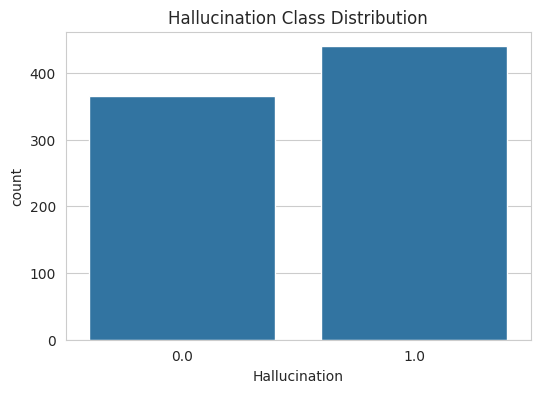

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Hallucination"
)

plt.title(
    "Hallucination Class Distribution"
)

plt.show()

In [12]:
text_columns = [
    "Question",
    "Ground_Truth",
    "Response"
]


df_ml = df.drop(
    columns=text_columns
)


df_ml.head()

,Category,Type,Model,SemanticSimilarity,BLEU,ROUGE1,ROUGEL,BERTScore,ResponseLength,GroundTruthLength,QuestionLength,LengthDifference,ResponseCharacters,AverageWordLength,Hallucination
0,Misconceptions,Adversarial,OpenAI,0.899544,2.341812e-01,0.645161,0.645161,0.945310,21,10,10,11,134,6.380952,0.0
1,Misconceptions,Adversarial,OpenAI,0.880159,3.421648e-155,0.301887,0.150943,0.912198,43,8,9,35,270,6.279070,0.0
2,Misconceptions,Adversarial,OpenAI,0.830584,1.367919e-01,0.312500,0.312500,0.906942,51,12,9,39,306,6.000000,0.0
3,Misconceptions,Adversarial,OpenAI,0.847144,5.550803e-02,0.257143,0.257143,0.911087,57,12,17,45,301,5.280702,0.0
4,Misconceptions,Adversarial,OpenAI,0.863956,9.458362e-02,0.338462,0.338462,0.908339,51,14,12,37,307,6.019608,0.0


In [13]:
df_ml.columns

Index(['Category', 'Type', 'Model', 'SemanticSimilarity', 'BLEU', 'ROUGE1',
       'ROUGEL', 'BERTScore', 'ResponseLength', 'GroundTruthLength',
       'QuestionLength', 'LengthDifference', 'ResponseCharacters',
       'AverageWordLength', 'Hallucination'],
      dtype='object')

In [14]:
category_encoder = LabelEncoder()


df_ml["Category"] = category_encoder.fit_transform(
    df_ml["Category"]
)

In [15]:
df_ml["Category"].head()

,Category
0,20
1,20
2,20
3,20
4,20


In [16]:
df_ml["Model"].head()

,Model
0,OpenAI
1,OpenAI
2,OpenAI
3,OpenAI
4,OpenAI


In [22]:
from sklearn.preprocessing import LabelEncoder
import joblib


model_encoder = LabelEncoder()


df_ml["Model"] = model_encoder.fit_transform(
    df_ml["Model"]
)

joblib.dump(
    model_encoder,
    "/content/drive/MyDrive/factcheckAI/outputs/model_encoder.pkl"
)

print("Model encoder created and saved successfully")

df_ml["Model"].head()

Model encoder created and saved successfully


,Model
0,2
1,2
2,2
3,2
4,2


In [23]:
#verifying variable
print(model_encoder.classes_)

[0 1 2]


In [24]:
joblib.dump(
    category_encoder,
    "/content/drive/MyDrive/factcheckAI/outputs/category_encoder.pkl"
)

print("Category encoder saved")

Category encoder saved


In [26]:
X = df_ml.drop(
    columns=["Hallucination"]
)

y = df_ml["Hallucination"]

In [27]:
print("Features:")
print(X.shape)

print("\nTarget:")
print(y.shape)

Features:
(806, 14)

Target:
(806,)


In [28]:
X.columns

Index(['Category', 'Type', 'Model', 'SemanticSimilarity', 'BLEU', 'ROUGE1',
       'ROUGEL', 'BERTScore', 'ResponseLength', 'GroundTruthLength',
       'QuestionLength', 'LengthDifference', 'ResponseCharacters',
       'AverageWordLength'],
      dtype='object')

In [29]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Category,806.0,16.292804,9.839387,0.000000,8.000000e+00,1.500000e+01,23.000000,37.000000
Model,806.0,1.011166,0.825750,0.000000,0.000000e+00,1.000000e+00,2.000000,2.000000
SemanticSimilarity,806.0,0.525109,0.361679,-0.103052,1.377704e-01,5.533822e-01,0.872274,1.000000
BLEU,806.0,0.065472,0.123922,0.000000,7.005138e-232,2.705404e-155,0.104350,0.925391
ROUGE1,806.0,0.246659,0.225515,0.000000,6.666667e-02,1.791045e-01,0.391304,1.000000
ROUGEL,806.0,0.222246,0.212292,0.000000,5.992763e-02,1.504717e-01,0.347826,1.000000
BERTScore,806.0,0.874458,0.049172,0.779966,8.316195e-01,8.644074e-01,0.914751,1.000000
ResponseLength,806.0,39.135236,17.125632,1.000000,2.800000e+01,4.100000e+01,49.000000,179.000000
GroundTruthLength,806.0,7.646402,4.508959,1.000000,4.000000e+00,7.000000e+00,11.000000,24.000000
QuestionLength,806.0,12.078164,6.822330,3.000000,7.250000e+00,1.000000e+01,14.000000,50.000000


In [31]:
X.select_dtypes(include="object").columns

Index(['Type'], dtype='object')

In [32]:
df_ml["Category"].unique()

array([20, 23,  4, 36,  8, 24, 12, 14, 15, 13,  5, 35, 30, 18, 34, 26, 25,
       28, 10, 29, 32,  6, 27, 17, 16,  2,  3,  1,  9, 31, 37, 22, 33, 11,
       19,  0, 21,  7])

In [33]:
from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()

df_ml["Category"] = category_encoder.fit_transform(
    df_ml["Category"]
)

df_ml["Category"].head()

,Category
0,20
1,20
2,20
3,20
4,20


In [34]:
X = df_ml.drop(
    columns=["Hallucination"]
)

y = df_ml["Hallucination"]

In [35]:
X.select_dtypes(include="object").columns

Index(['Type'], dtype='object')

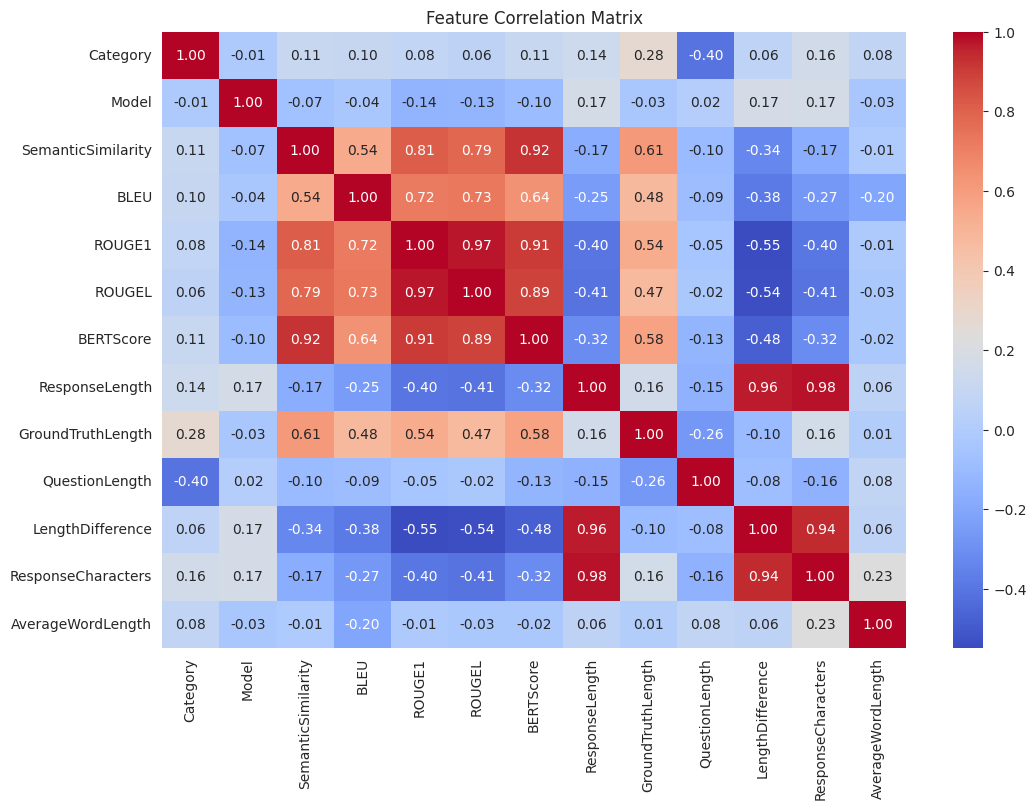

In [37]:
numeric_X = X.select_dtypes(
    include=["int64", "float64"]
)


plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

In [38]:
X.select_dtypes(include="object").columns

Index(['Type'], dtype='object')

In [40]:
X.dtypes

,0
Category,int64
Type,object
Model,int64
SemanticSimilarity,float64
BLEU,float64
ROUGE1,float64
ROUGEL,float64
BERTScore,float64
ResponseLength,int64
GroundTruthLength,int64


In [41]:
from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()

df_ml["Category"] = category_encoder.fit_transform(
    df_ml["Category"]
)

df_ml["Category"].head()

,Category
0,20
1,20
2,20
3,20
4,20


In [42]:
X = df_ml.drop(
    columns=["Hallucination"]
)

y = df_ml["Hallucination"]

In [43]:
X.select_dtypes(include="object").columns

Index(['Type'], dtype='object')

In [44]:
X.dtypes

,0
Category,int64
Type,object
Model,int64
SemanticSimilarity,float64
BLEU,float64
ROUGE1,float64
ROUGEL,float64
BERTScore,float64
ResponseLength,int64
GroundTruthLength,int64


In [48]:
X.head()

,Category,Type,Model,SemanticSimilarity,BLEU,ROUGE1,ROUGEL,BERTScore,ResponseLength,GroundTruthLength,QuestionLength,LengthDifference,ResponseCharacters,AverageWordLength
0,20,Adversarial,2,0.899544,2.341812e-01,0.645161,0.645161,0.945310,21,10,10,11,134,6.380952
1,20,Adversarial,2,0.880159,3.421648e-155,0.301887,0.150943,0.912198,43,8,9,35,270,6.279070
2,20,Adversarial,2,0.830584,1.367919e-01,0.312500,0.312500,0.906942,51,12,9,39,306,6.000000
3,20,Adversarial,2,0.847144,5.550803e-02,0.257143,0.257143,0.911087,57,12,17,45,301,5.280702
4,20,Adversarial,2,0.863956,9.458362e-02,0.338462,0.338462,0.908339,51,14,12,37,307,6.019608


In [49]:
X.dtypes

,0
Category,int64
Type,object
Model,int64
SemanticSimilarity,float64
BLEU,float64
ROUGE1,float64
ROUGEL,float64
BERTScore,float64
ResponseLength,int64
GroundTruthLength,int64


In [50]:
df_ml["Category"] = category_encoder.fit_transform(
    df_ml["Category"]
)

In [51]:
X = df_ml.drop(
    columns=["Hallucination"]
)

y = df_ml["Hallucination"]

In [52]:
X.dtypes

,0
Category,int64
Type,object
Model,int64
SemanticSimilarity,float64
BLEU,float64
ROUGE1,float64
ROUGEL,float64
BERTScore,float64
ResponseLength,int64
GroundTruthLength,int64


In [54]:
from sklearn.preprocessing import LabelEncoder

type_encoder = LabelEncoder()

X["Type"] = type_encoder.fit_transform(
    X["Type"]
)

X["Type"].head()

,Type
0,0
1,0
2,0
3,0
4,0


In [55]:
X.dtypes

,0
Category,int64
Type,int64
Model,int64
SemanticSimilarity,float64
BLEU,float64
ROUGE1,float64
ROUGEL,float64
BERTScore,float64
ResponseLength,int64
GroundTruthLength,int64


In [56]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [ ]:
import joblib

joblib.dump(
    type_encoder,
    "/content/drive/MyDrive/factcheckAI/outputs/type_encoder.pkl"
)

print("Type encoder saved")

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Category,Type,Model,SemanticSimilarity,BLEU,ROUGE1,ROUGEL,BERTScore,ResponseLength,GroundTruthLength,QuestionLength,LengthDifference,ResponseCharacters,AverageWordLength
0,0.377005,-1.061437,1.198242,1.035910,1.362258,1.768177,1.993371,1.441773,-1.059610,0.522307,-0.304801,-1.218744,-0.988007,0.277804
1,0.377005,-1.061437,1.198242,0.982280,-0.528660,0.245049,-0.336080,0.767974,0.225811,0.078470,-0.451470,0.204031,0.239399,0.117409
2,0.377005,-1.061437,1.198242,0.845126,0.575879,0.292140,0.425402,0.661024,0.693238,0.966143,-0.451470,0.441160,0.564300,-0.321932
3,0.377005,-1.061437,1.198242,0.890940,-0.080456,0.046517,0.164481,0.745370,1.043807,0.966143,0.721878,0.796854,0.519175,-1.454328
4,0.377005,-1.061437,1.198242,0.937451,0.235064,0.407333,0.547769,0.689444,0.693238,1.409980,-0.011464,0.322596,0.573325,-0.291063


In [58]:
import joblib

joblib.dump(
    scaler,
    "/content/drive/MyDrive/factcheckAI/outputs/scaler.pkl"
)

print("Scaler saved successfully")

Scaler saved successfully


In [59]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [60]:
print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (644, 14)
X_test: (162, 14)
y_train: (644,)
y_test: (162,)


In [61]:
print("Training Labels")

print(
    y_train.value_counts()
)

Training Labels
Hallucination
1.0    352
0.0    292
Name: count, dtype: int64


In [62]:
print("Testing Labels")

print(
    y_test.value_counts()
)

Testing Labels
Hallucination
1.0    88
0.0    74
Name: count, dtype: int64


In [63]:
print("Training Percentage")

print(
    y_train.value_counts(normalize=True)*100
)


print("\nTesting Percentage")

print(
    y_test.value_counts(normalize=True)*100
)

Training Percentage
Hallucination
1.0    54.658385
0.0    45.341615
Name: proportion, dtype: float64

Testing Percentage
Hallucination
1.0    54.320988
0.0    45.679012
Name: proportion, dtype: float64


In [64]:
output_path = "/content/drive/MyDrive/factcheckAI/outputs/"

In [65]:
X_train.to_csv(
    output_path + "X_train.csv",
    index=False
)

In [66]:
X_test.to_csv(
    output_path + "X_test.csv",
    index=False
)

In [67]:
y_train.to_csv(
    output_path + "y_train.csv",
    index=False
)

In [68]:
y_test.to_csv(
    output_path + "y_test.csv",
    index=False
)

In [69]:
feature_names = list(X.columns)

feature_names

['Category',
 'Type',
 'Model',
 'SemanticSimilarity',
 'BLEU',
 'ROUGE1',
 'ROUGEL',
 'BERTScore',
 'ResponseLength',
 'GroundTruthLength',
 'QuestionLength',
 'LengthDifference',
 'ResponseCharacters',
 'AverageWordLength']

In [70]:
joblib.dump(
    feature_names,
    output_path + "feature_names.pkl"
)

print("Feature names saved")

Feature names saved


In [71]:
import os

files = os.listdir(
    "/content/drive/MyDrive/factcheckAI/outputs"
)

files

['model_metric_summary.csv',
 'potential_hallucinations.csv',
 'category_metric_summary.csv',
 'metric_summary.csv',
 'responses_test.csv',
 'groq_responses.csv',
 'deepseek_responses.csv',
 'openai_responses.csv',
 'evaluation_checkpoint.csv',
 'merged_responses.csv',
 'evaluation_dataset.csv',
 'manual_annotation_sample.csv.gsheet',
 'manual_annotation_sample.csv',
 'manual_review.csv',
 'high_confidence_labels.csv',
 'uncertain_responses.csv',
 'ml_dataset.csv',
 'training_dataset.csv',
 'category_encoder.pkl',
 'model_encoder.pkl',
 'scaler.pkl',
 'X_train.csv',
 'X_test.csv',
 'y_train.csv',
 'y_test.csv',
 'feature_names.pkl']

In [72]:
print("DATA PREPROCESSING COMPLETE")
print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

print(
    "Number of features:",
    X_train.shape[1]
)

DATA PREPROCESSING COMPLETE
Training samples: 644
Testing samples: 162
Number of features: 14
